# Summary - Acme4 Processes EDA and basic Classification

1. Load data from ```process_uber_summary``` table and flag *badusers* -- we'll use "baduser" processes as positive labels, and others as negative labels
2. Build a simple random forest classifier with numerical features from that table and look at: (i) classification performance (recovering baduser processes), (ii) conditional feature distributions, and (iii) feature importance
3. Explore ```sigma_labels``` for classification purpose
4. Also try a simple CART model for easy interpretability
5. Try classification aimed at recovering "negative labels" (for filtering purpose)
6. Try a different train/test split based on baduser ids

### References

* https://github.com/llnl/Wintap-Analytics/tree/main/2025-acme4-explore
* https://gdo168.llnl.gov/
* https://gdo168.llnl.gov/data/newdocs/datadict/
  

# Introduction

The first few cells are taken from BH's ```process-name-curation``` notebook


In [1]:
%load_ext autoreload
%load_ext dotenv
#%load_ext quak 
%load_ext sql
    

In [2]:
%autoreload 1
%aimport acme4_explore

In [3]:
%%time
import acme4_explore
import io
import logging as lg
import numpy as np
import os
import pandas as pd
import re
from tqdm.auto import tqdm, trange
from collections import Counter
import warnings

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz


CPU times: user 4.98 s, sys: 60.6 ms, total: 5.04 s
Wall time: 503 ms


In [4]:
# Registers the current `tqdm` class with pandas.core.
tqdm.pandas()


In [5]:
lg.basicConfig(**acme4_explore.logging_config())
LOG = lg.getLogger("notebook")


In [6]:
db = acme4_explore.connect_db()
%sql db --alias duckdb
%config SqlMagic.displaycon=False
%config SqlMagic.autopandas=True


# (1) Get data from the ```process_uber_summary``` table

* Flag processes from "badusers"
* Drop some numerical features too closely correlated with the baduser label
* Impute missing values


In [7]:
%%sql process <<
select * from process_uber_summary


In [8]:
## numerical features
num_col = process.select_dtypes(include=np.number).columns.tolist()
Drop = ['process_started_seconds', 'process_stop_seconds', 'parent_os_pid', 'os_pid', 'token_elevation_type']
# drop those - correlated with bad user's activity
for x in Drop:
    num_col.remove(x)

## flag badusers
process['is_bad'] = process['baduser'] = 0
process.loc[process["user_name"].isna(), "user_name"] = ""
process.loc[process["user_name"].str.contains("baduser") , "is_bad"] = 1
process.loc[process["user_name"]=="", "user_name"] = '<NA>'
print(process.is_bad.value_counts())

## identify the badusers
process['baduser'] = 0
process.loc[process["user_name"].str.contains("baduser3") , "baduser"] = 3
process.loc[process["user_name"].str.contains("baduser9") , "baduser"] = 9
process.loc[process["user_name"].str.contains("baduser25") , "baduser"] = 25
Counter(process.baduser)


is_bad
0    1771882
1       1084
Name: count, dtype: int64


Counter({0: 1771882, 3: 644, 9: 400, 25: 40})

### Impute missing values / drop some feature

While models such as random forest or CART can handle missing values, we can also impute those beforehand, in particular in cases when assigning some value (such as 0) makes sense.


In [9]:
## missing values
Missing = dict(zip(process[num_col].isnull().sum().keys(), process[num_col].isnull().sum().values))
Ctr = Counter(Missing)
Drop = []
Impute = []
## for each feature, look at the range of values and number of missing values
## go in descending order of missing value counts
for feature in [x[0] for x in Ctr.most_common()]:
    if len(process[feature].dropna())>0:
        ## features with non-negative values, for which to replace NA with 0 
        if (min(process[feature].dropna())>=0) & (max(process[feature].dropna())>0) & (sum(process[feature].isna())>0):
            Impute.append(feature)
        else:
            ## features to look at and decide
            if (sum(process[feature].isna())>0):
                print(feature, min(process[feature].dropna()), max(process[feature].dropna()), sum(process[feature].isna()))
    else:
        ## features to drop -- no values
        Drop.append(feature)
    

Close_Events 0.0 0.0 1282034
Create_Events 0.0 0.0 1282034
Delete_Events 0.0 0.0 1282034
Rename_Events 0.0 0.0 1282034
SetInfo_Events 0.0 0.0 1282034
Read_Bytes -8620107115.0 28525724502.0 1282034
Write_Bytes -4608447604.0 58307904401.0 1282034
num_null_filename 0.0 0.0 1282034
cpu_utilization 0 0 259206
exit_code -2147483645 1879048193 259206


In [10]:
## Drop those - all non-na values are 0 or range is doubtful
Drop.extend(['Close_Events', 'Create_Events' , 'Delete_Events' , 'Rename_Events' , 'SetInfo_Events', 'num_null_filename','cpu_utilization','exit_code','Read_Bytes','Write_Bytes'])
for feature in Drop:
    num_col.remove(feature)

## Impute
for feature in Impute:
    process[feature] = process[feature].fillna(0) ## impute with 0 ; another common option is to use the median 


### quick eda

In [11]:
# number of unique PIDs
print(process.shape)
len(set(process['pid_hash']))


(1772966, 132)


1772947

In [12]:
# drop dupes
dupes = [int(i) for i in (np.where(process[['pid_hash']].duplicated())[0])]
process.drop(dupes, inplace=True)
print(process.shape)
len(set(process['pid_hash']))


(1772947, 132)


1772947

In [13]:
## most common filenames with bad users - 
Counter(process[process.is_bad==1].filename).most_common(5)


[('c:\\program files (x86)\\microsoft\\edge\\application\\msedge.exe', 325),
 ('c:\\program files\\mozilla firefox\\firefox.exe', 125),
 ('c:\\windows\\system32\\cleanmgr.exe', 85),
 ('c:\\windows\\system32\\dllhost.exe', 58),
 ('c:\\windows\\system32\\conhost.exe', 37)]

In [14]:
Counter(process['high_num_sigma_hits'])

Counter({np.int64(1): 1186004,
         np.int64(2): 469511,
         np.int64(3): 93838,
         np.int64(0): 15427,
         np.int64(4): 7969,
         np.int64(5): 99,
         np.int64(6): 92,
         np.int64(8): 6,
         np.int64(7): 1})

# (2) Random forest classification model 

Typical classification task with:
* 50/50 split for training and testing
* Report performance via confusion matrix, AUC and ROC curve
* Permutation-based feature importance (a la L. Breiman)
* A posteriori, look at feature distributions conditioned on the baduser label

Observations:
* Severe class imbalance, obviously
* Remarkable ROC curve and AUC value
* Surprizingly few false positives, but several false negatives
* Confusion matrix indicates classification could also be used to filter most "non-badusers"
* Several top features involve the sigma labels

**NB:** RF handles missing values by grouping those observations (during training) and sending them down the branch that maximizes gain ; the same decision is applied to test data (if there were no missing values in training, missing values is test phase go down the most popular branch).


In [15]:
## simple random forest
X = process[num_col]
y = process['is_bad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
rf = RandomForestClassifier(n_jobs=25)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### confusion matrix


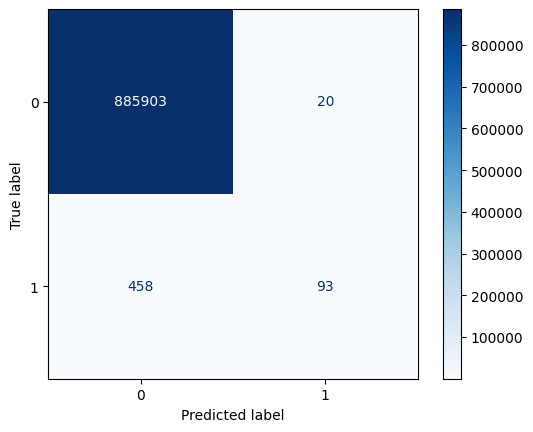

In [16]:
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


### variable permutation importance -- this takes a few minutes


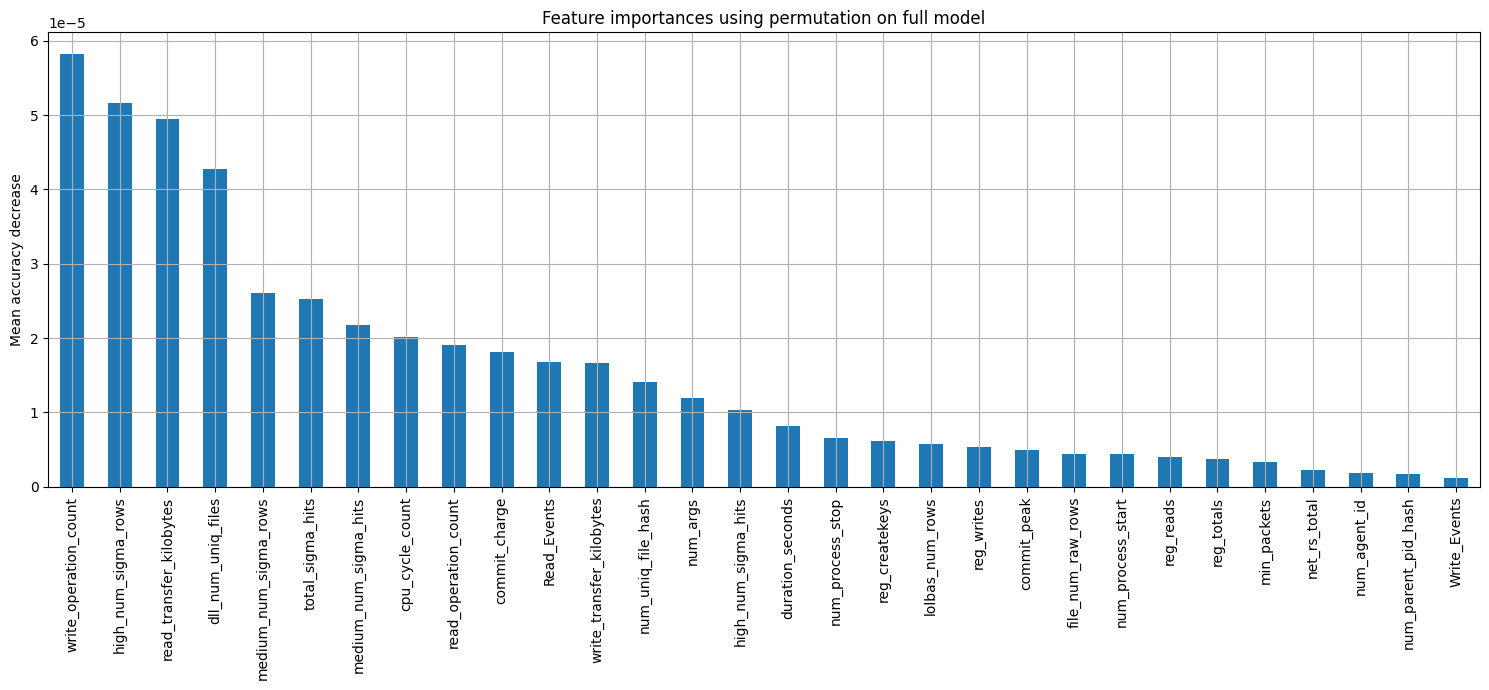

In [17]:
result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=4
)

## plot top ones
_top = 30
forest_importances = pd.Series(result.importances_mean, index=num_col).sort_values(ascending=False)[:_top]
fig, ax = plt.subplots(figsize=(15,7))
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.grid()
plt.show()


### AUC and ROC curve


AUC:, 0.9842394708738693


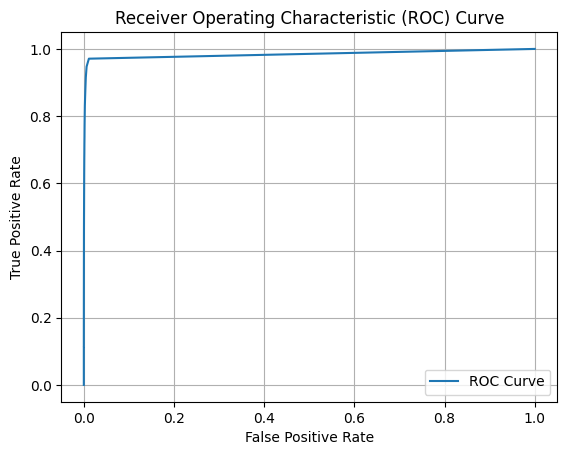

In [18]:
y_pred_proba = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print('AUC:,',auc(fpr, tpr))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


### top features -- conditional distributions


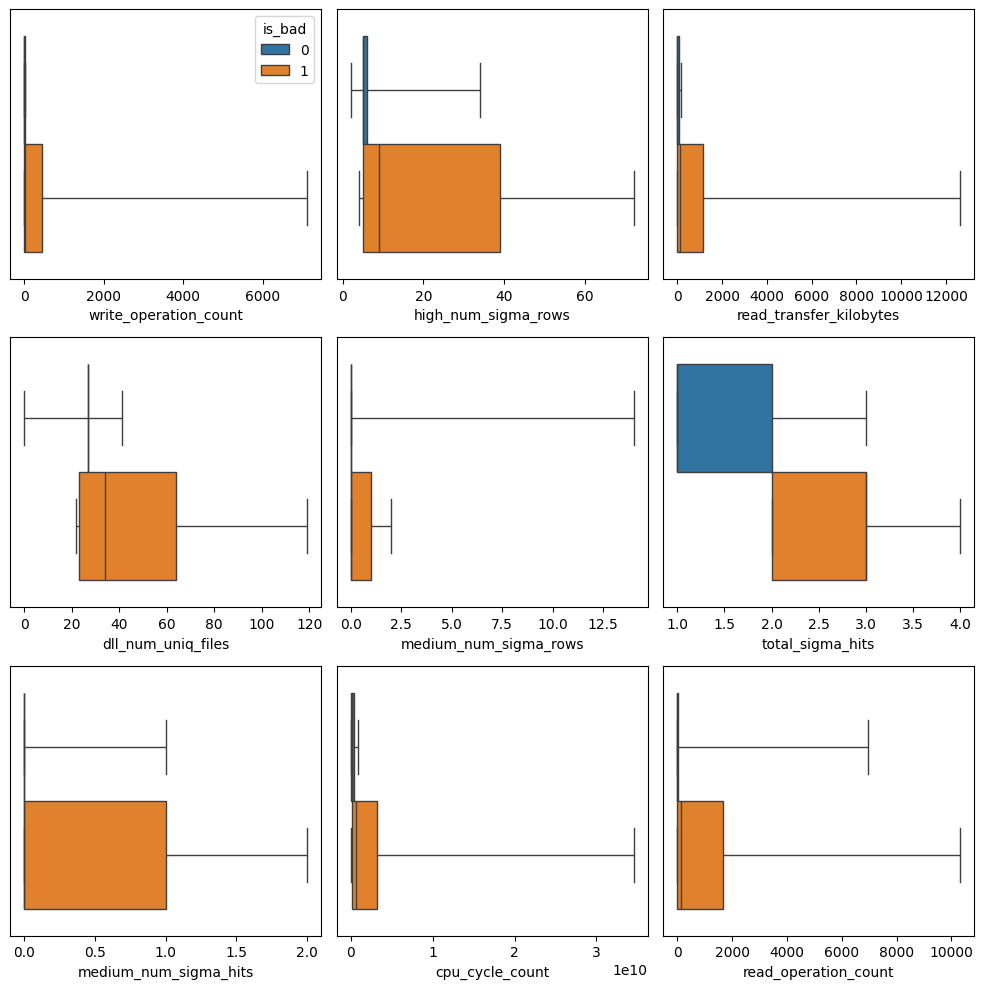

In [19]:
%%capture --no-display

fig, axes = plt.subplots(3,3, figsize=(10, 10))
ctr = 0
for col in list(forest_importances.keys())[:9]:
    ax = sns.boxplot(data=process, x=col, showfliers=False, hue='is_bad', ax=axes[ctr//3,ctr%3], legend=(ctr==0), whis=(5,95))
    ax.set(yticks=[]) 
    ctr+=1
plt.tight_layout()


# (3) Exploring the sigma labels

The Mitre labels do not seem helpful for this classification task, but sigma labels appear in top features, so we expand on those.
We gather those from the ```sigma_labels``` table.

Observations:
* a simple sum of the number of sigma "events" does well at discriminating badusers ; this aligns with the fact that feature ```high_num_sigma_rows``` is amongst the top in importance for supervised learning
* some sigma analytics are very common ; summing 1/frequency instead for the sigma events does a bit better


In [20]:
%%sql sigma <<
select * from sigma_labels


In [21]:
## some sigma ids are very common!
Counter(sigma.analytic_id).most_common(5)


[('4fc0deee-0057-4998-ab31-d24e46e0aba4', 12303554),
 ('f208d6d8-d83a-4c2c-960d-877c37da84e5', 5501388),
 ('71158e3f-df67-472b-930e-7d287acaa3e1', 5042822),
 ('9d7ca793-f6bd-471c-8d0f-11e68b2f0d2f', 1925188),
 ('e4a6b256-3e47-40fc-89d2-7a477edd6915', 594966)]

### compute scores 

* sum of counts
* sum of inverse frequencies


In [22]:
%%time
_sigma_dict = sigma["analytic_id"].value_counts().to_dict()
sigma['inv_freqs'] = [1/_sigma_dict[x] for x in sigma.analytic_id]
sigma['counts'] = 1
_sigma = sigma.groupby(by='entity', as_index=False)[['inv_freqs','counts']].sum()

## add count-based score
_sigma_dict = dict(zip(_sigma['entity'], _sigma['counts']))
process['score_counts'] = [_sigma_dict.get(x,0) for x in process['pid_hash']]

## add inverse frequency based score
_sigma_dict = dict(zip(_sigma['entity'], _sigma['inv_freqs']))
process['score_inv_freqs'] = [_sigma_dict.get(x,0) for x in process['pid_hash']]


CPU times: user 25.2 s, sys: 957 ms, total: 26.1 s
Wall time: 26.1 s


### using the counts score as sole predictor

this is clearly better than random, with a number of "early hits" on the ROC curve


AUC:, 0.8019411398896752


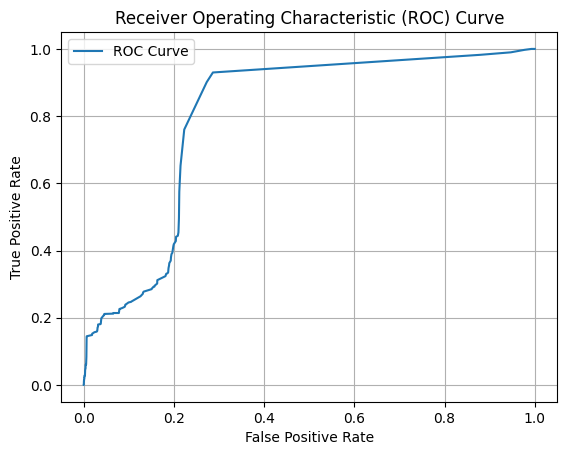

In [23]:
fpr, tpr, thresholds = roc_curve(process.is_bad, process.score_counts)
print('AUC:,',auc(fpr, tpr))
plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


### using the inverse frequencies score as sole predictor

this is even better than random, with a lot of "early hits" on the ROC curve and higher AUC

next we add this feature to our random forest model


AUC:, 0.8776452542530271


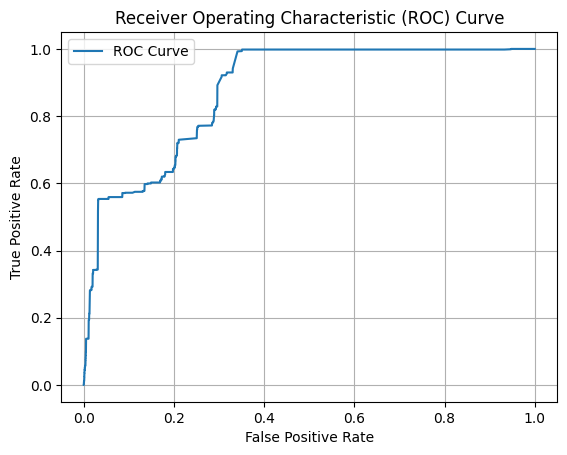

In [24]:
fpr, tpr, thresholds = roc_curve(process.is_bad, process.score_inv_freqs)
print('AUC:,',auc(fpr, tpr))
plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


### Adding the inverse frequency sigma-based feature to our simple forest model

ROC curve is almost the same, but we see the inverse frequency score as the second most important feature.


In [25]:
num_col.append('score_inv_freqs')


In [26]:
## random forest
X = process[num_col]
y = process['is_bad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)
rf = RandomForestClassifier(n_jobs=25)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


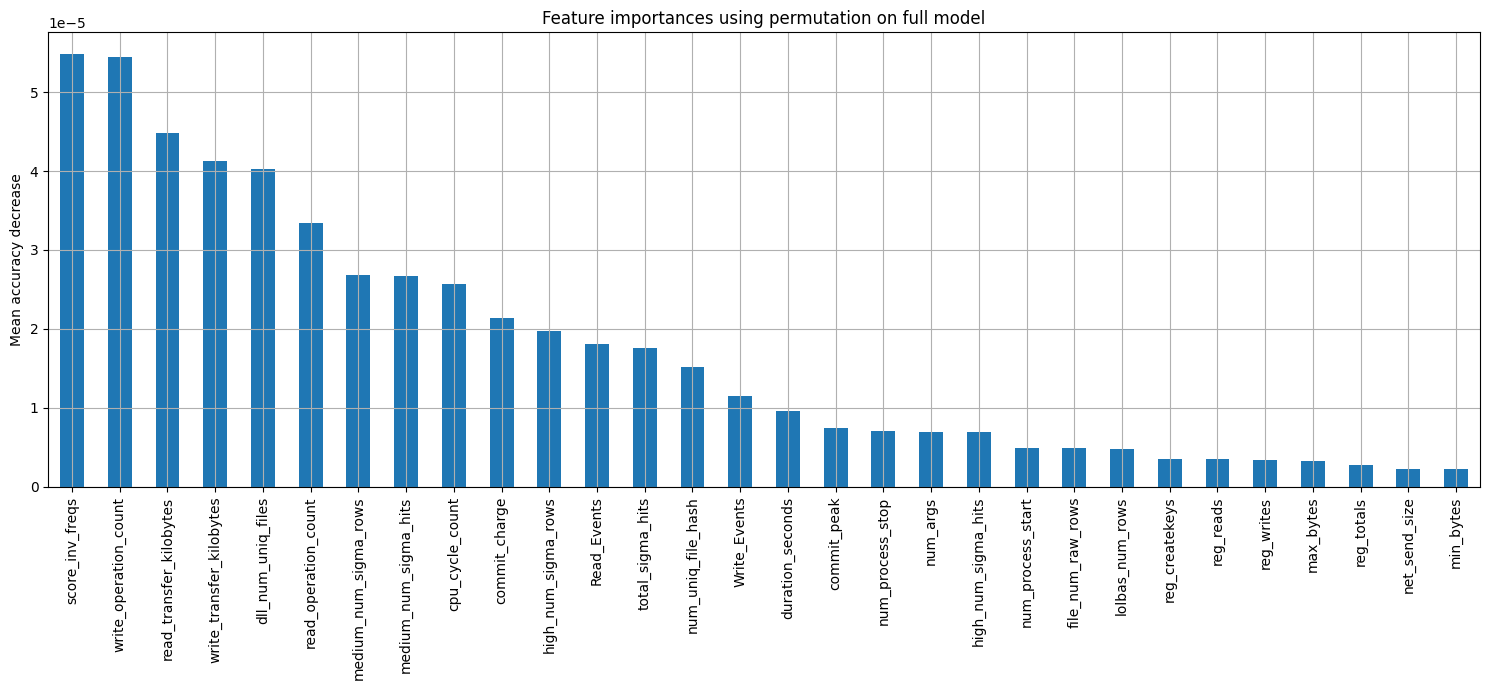

In [27]:
## variable importance
result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=4
)

## plot top ones
_top = 30
forest_importances = pd.Series(result.importances_mean, index=num_col).sort_values(ascending=False)[:_top]
fig, ax = plt.subplots(figsize=(15,7))
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.grid()
plt.show()


AUC:, 0.9869118308631152


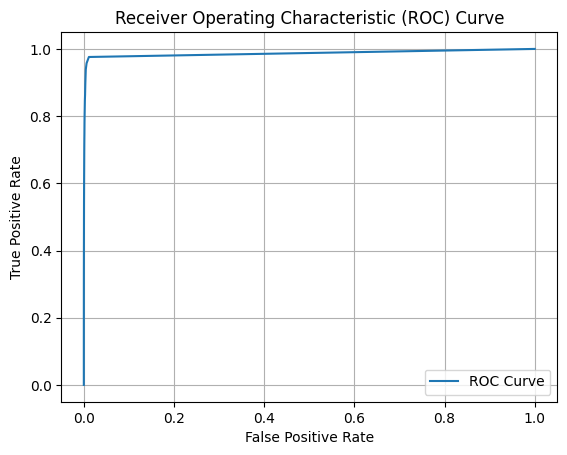

In [28]:
## ROC and AUC
y_pred_proba = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print('AUC:,',auc(fpr, tpr))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


### precision, recall and F1 vs threshold


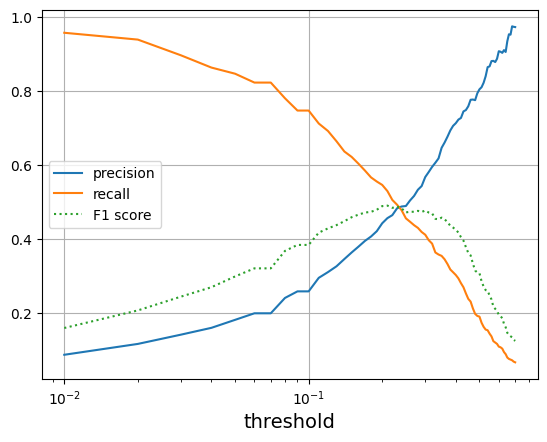

In [29]:
L = []
for th in np.arange(.01,.71,.01):
    y_pred = y_pred_proba > th
    cm = confusion_matrix(y_test,y_pred)
    fp = cm[0,1]
    tp = cm[1,1]
    fn = cm[1,0]
    F = 2*tp/(2*tp+fp+fn)
    L.append([th, fp, tp, fn, tp/(tp+fp), tp/(tp+fn), F])

_df = pd.DataFrame(L, columns=['weight','fp','tp','fn','precision','recall','F1'])
plt.semilogx(_df.weight, _df.precision, label='precision')
plt.semilogx(_df.weight, _df.recall, label='recall')
plt.semilogx(_df.weight, _df.F1, label='F1 score', ls=':')
plt.grid()
plt.xlabel('threshold', fontsize=14)
plt.legend();


# (4) A simple CART classification model

In view of the above results, we try a simple, very interpretable classification tree using the same approach.

We can actually visualize the top splits in the tree.

Results from the confusion matrix are only slightly worse than with a random forest.

**NB:** with decision trees, missing values are lumped together and assigned to the split that yields the best score, as with RFs


In [30]:
## Fit the model
from sklearn.tree import DecisionTreeClassifier
X = process[num_col]
y = process['is_bad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


### handling class imbalance


In [31]:
print('imbalance factor:',1/(sum(y_train)/len(y_train)))
L = []
for rw in [1,2,3,4,5,6,7,8,9,10,15,20,30,40,50,100,1000]:
    cart = DecisionTreeClassifier(random_state=321, max_depth=6, class_weight={0:1, 1:rw}) ## re-weight due to class imbalance
    cart.fit(X_train, y_train)
    y_pred = cart.predict(X_test)
    cm = confusion_matrix(y_test,y_pred)
    fp = cm[0,1]
    tp = cm[1,1]
    fn = cm[1,0]
    F = 2*tp/(2*tp+fp+fn)
    L.append([rw, fp, tp, fn, tp/(tp+fp), tp/(tp+fn), F])
    

imbalance factor: 1663.1763602251408


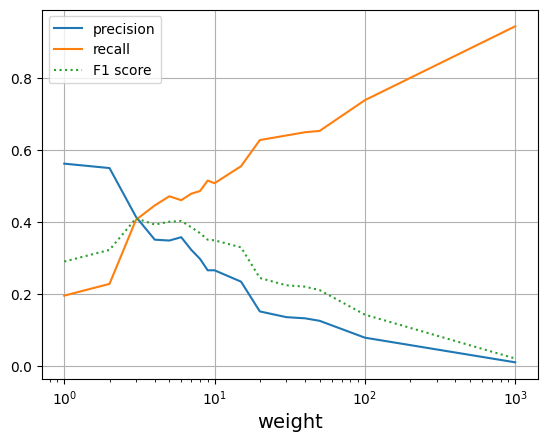

In [32]:
_df = pd.DataFrame(L, columns=['weight','fp','tp','fn','precision','recall','F1'])
plt.semilogx(_df.weight, _df.precision, label='precision')
plt.semilogx(_df.weight, _df.recall, label='recall')
plt.semilogx(_df.weight, _df.F1, label='F1 score', ls=':')
plt.grid()
plt.xlabel('weight', fontsize=14)
plt.legend();


In [33]:
## optimal weight w.r.t. F1 score
w_f1 = int(_df.weight[_df.F1 == max(_df.F1)].iloc[0])


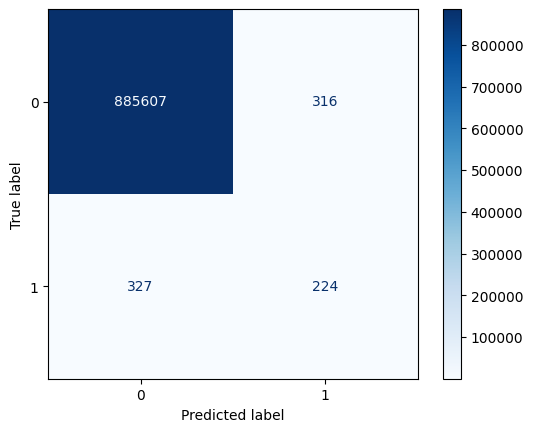

In [34]:
# Create a DecisionTreeClassifier instance
cart = DecisionTreeClassifier(random_state=321, max_depth=6, class_weight={0:1, 1:w_f1}) ## re-weight with optimal 

# Train the classifier
cart.fit(X_train, y_train)

# Make predictions
y_pred = cart.predict(X_test)

## Confusion matrix
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


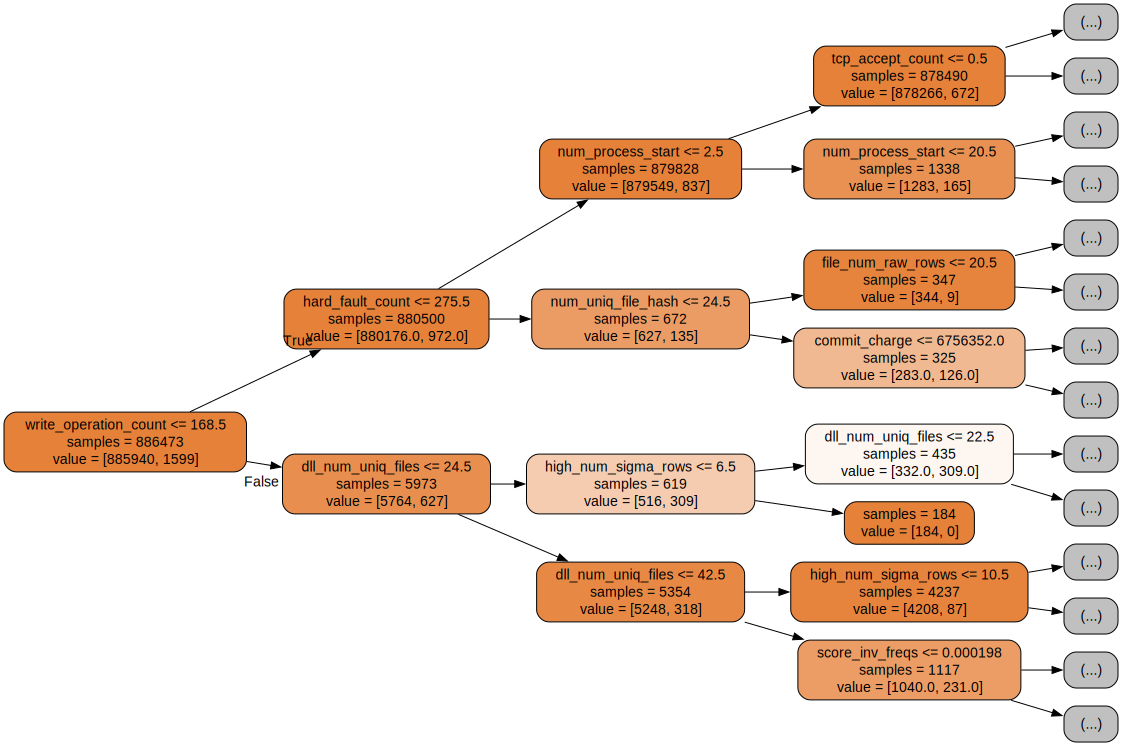

In [35]:
## nb: counts are "off" due to re-weighting
dot_data = export_graphviz(cart,
                           feature_names=X_train.columns,  
                           filled=True,  
                           max_depth=3, 
                           precision=6,
                           rotate=True,
                           impurity=False, 
                           rounded=True,
                           proportion=False)
graph = graphviz.Source(dot_data)
display(graph)


# (5) Reverse the labels - try dropping "likely ok stuff"

This is really the same model, but we look at the confusion matrix for the angle of dropping "non-bad" processes.

Adjusting the threshold, we can remove most "non-bad" while retaining a large proportion of the baduser processes.


In [36]:
## simple random forest
X = process[num_col]
y = [not x for x in process['is_bad']] ## reverse the labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
rf = RandomForestClassifier(n_jobs=25)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


AUC:, 0.984305482190585


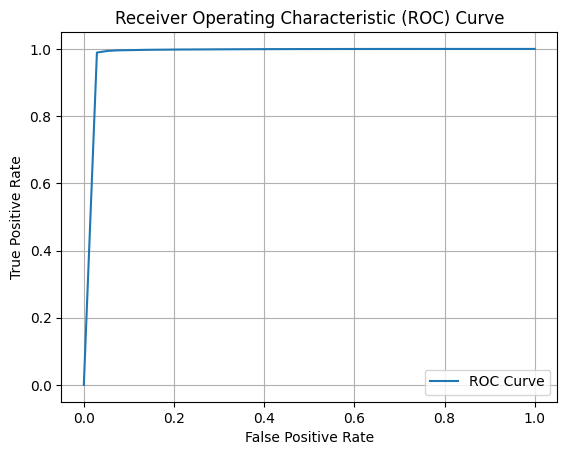

In [37]:
y_pred_proba = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print('AUC:,',auc(fpr, tpr))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


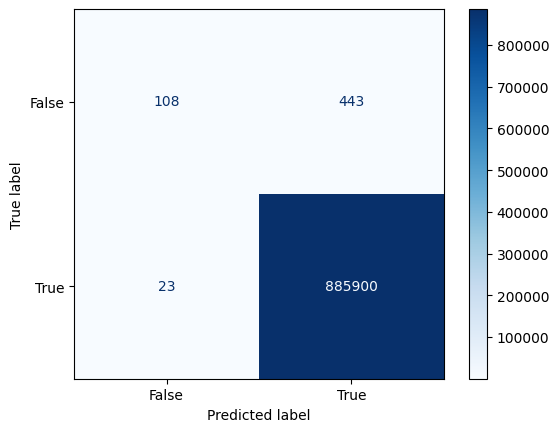

In [38]:
## mid range threshold
y_pred = y_pred_proba > .50
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


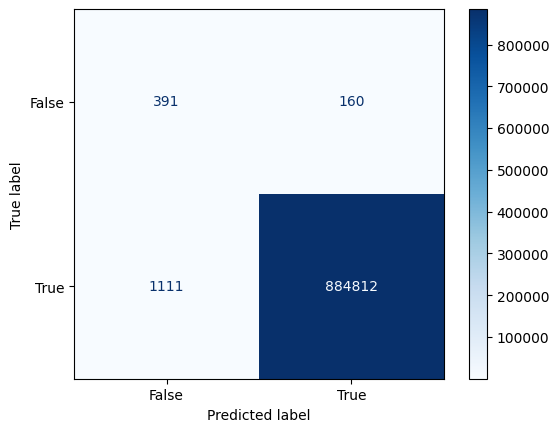

In [39]:
## high threshold
y_pred = y_pred_proba > .90
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


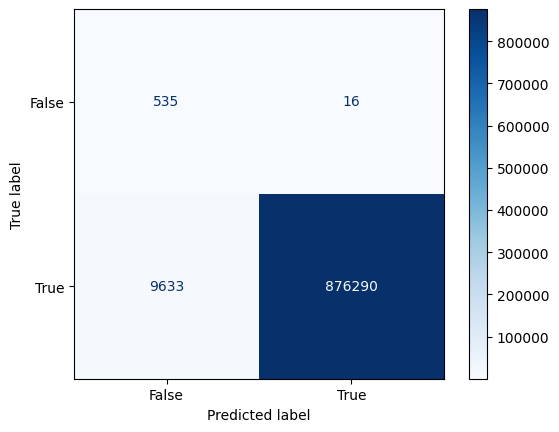

In [40]:
## very high threshold
y_pred = y_pred_proba > .99
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


# (6) A different train-test split

For the positive labels, consider trees involving the same baduser(s) for training, and a disjoint set of baduser(s) for testing.
There are only 3 'badusers', one of which has only 40 instances. Separating the other two between test/train yields similar results.
The ROC curve show that we can recover around 60% of the test set, but looking deeper, all probability scores are very low, with most cases getting 0 probability.
Thus there is some signal, but nowhere near the previous experiments. So in short:
* many badusers processes are easy to differentiate from the other processes
* processes from different badusers are also quite different, but have some simlarity that still allows to differentiate from "other" process in a weak fashion


In [41]:
## split negative cases randomly
X = process[process.baduser==0][num_col]
y = process[process.baduser==0]['is_bad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

## split positive cases by 'baduser'
bad_train = [9, 25]
bad_test = [3]

X_train = pd.concat([X_train,process[process.baduser.isin(bad_train)][num_col]], ignore_index=True)
X_test = pd.concat([X_test,process[process.baduser.isin(bad_test)][num_col]], ignore_index=True)
y_train = pd.concat([y_train, process[process.baduser.isin(bad_train)]['is_bad']], ignore_index=True)
y_test = pd.concat([y_test, process[process.baduser.isin(bad_test)]['is_bad']], ignore_index=True)


In [42]:
## simple random forest
rf = RandomForestClassifier(n_jobs=25, class_weight={0:1, 1:10})
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


AUC:, 0.7915962120937845


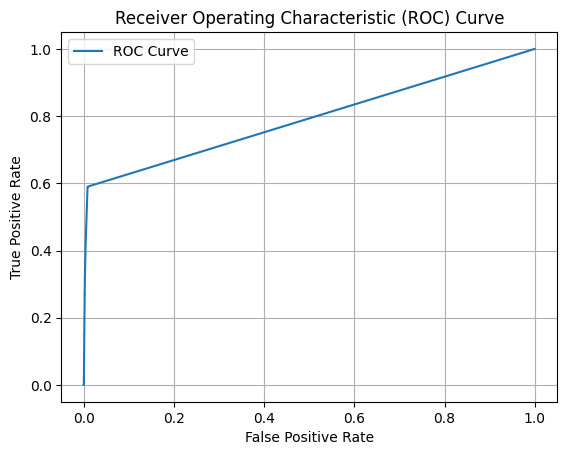

In [43]:
y_pred_proba = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print('AUC:,',auc(fpr, tpr))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


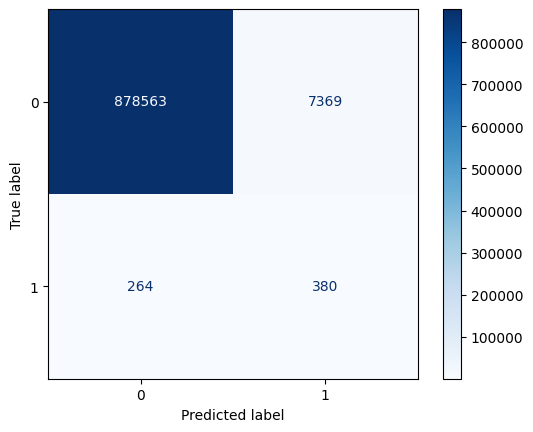

In [44]:
y_pred = y_pred_proba > 0
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


AUC:, 0.6475246587768104


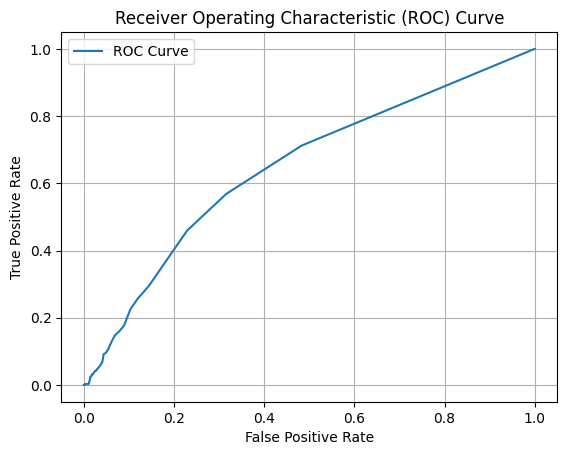

In [45]:
## ROC w.r.t. the positive scoring cases only ...
y_pred_proba = rf.predict_proba(X_test)[:,1]
b = y_pred_proba>0
fpr, tpr, thresholds = roc_curve(y_test[b], y_pred_proba[b])
print('AUC:,',auc(fpr, tpr))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


### look at paths in CART 

Quite different trees when looking at training or test datasets ... the badusers are not so similar after all ... 


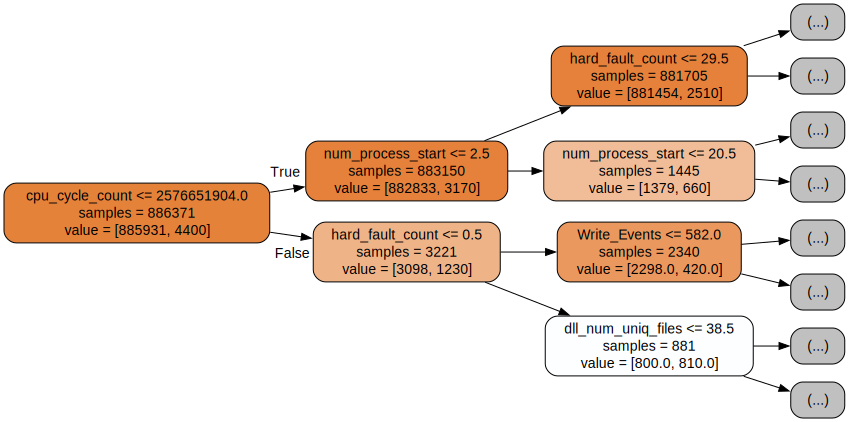

In [46]:
# Create a DecisionTreeClassifier instance - training data (baduser9 mainly)
cart = DecisionTreeClassifier(random_state=321, max_depth=6, class_weight={0:1, 1:10})
cart.fit(X_train, y_train)

dot_data = export_graphviz(cart,
                           feature_names=X.columns,  
                           filled=True,  
                           max_depth=2, 
                           precision=6,
                           rotate=True,
                           impurity=False, 
                           rounded=True,
                           proportion=False)
graph = graphviz.Source(dot_data)
display(graph)


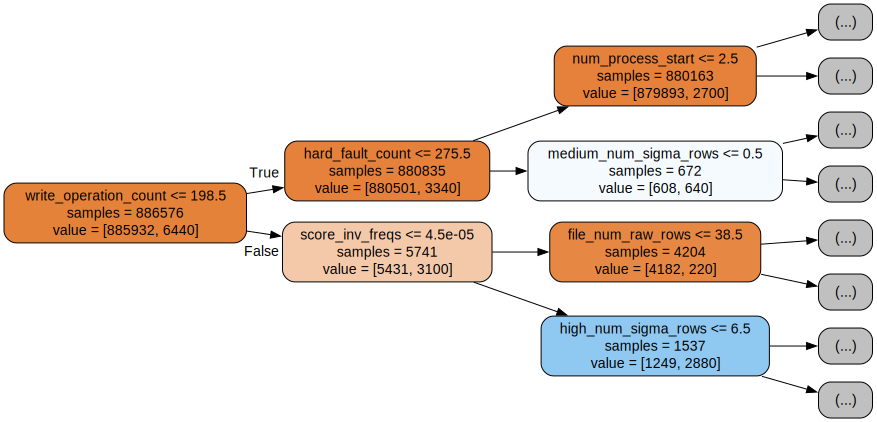

In [47]:
# Create a DecisionTreeClassifier instance - test data (baduser3)
## this is closer to the overall model we trained earlier, which was better at recovering baduser3 than baduser9

cart = DecisionTreeClassifier(random_state=321, max_depth=6, class_weight={0:1, 1:10})
cart.fit(X_test, y_test)

dot_data = export_graphviz(cart,
                           feature_names=X.columns,  
                           filled=True,  
                           max_depth=2, 
                           precision=6,
                           rotate=True,
                           impurity=False, 
                           rounded=True,
                           proportion=False)
graph = graphviz.Source(dot_data)
display(graph)
